<a href="https://colab.research.google.com/github/Saptaparnineogi/Customer-Churn-Prediction/blob/main/Telcom_Customer_Churn_Prediction_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from google.colab import files
import missingno as msno
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

Saving Churn.csv to Churn (1).csv


In [ ]:
uploadedfiles = files.upload()

In [53]:
churn_df = pd.read_csv("Churn.csv")
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Using this matrix we can very quickly find the pattern of missing values in the dataset.
From the above visualisation we can observe that it has no peculiar pattern that stands out. In fact there is no missing data.



In [56]:
churn_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [57]:
churn_df[['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']].isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


When we check in here we don't see any NULL values in the data. But after going through the data manually I see there are actually some missing values on `TotalCharges` column.

In [58]:
churn_df['TotalCharges'] = pd.to_numeric(churn_df.TotalCharges, errors='coerce')
churn_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


We see here TotalCharges column has 11 missing values in the data.
Let's have a look into the other column values when TotalCharges are Null.

In [59]:
churn_df[np.isnan(churn_df["TotalCharges"])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [60]:
print("Where we see 0 Tenure -")
churn_df[churn_df["tenure"]==0].index

Where we see 0 Tenure -


Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [61]:
churn_df = churn_df.dropna()

For these 11 columns tenure is also 0. On checking more we see tenure = 0 can be found out only for these 11 columns. As we have total 7043 rows in the data we can detele these 11 rows, as it is not going to affect the later predictive modelling very much. If we have more missing values I would have though about recalculating it. But at this scenario it's not very important.

In [62]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
churn_df[numerical_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [63]:
print(f"No churn: {churn_df[churn_df["Churn"]=="No"].count()["customerID"]}")
print(f"Churn: {churn_df[churn_df["Churn"]=="Yes"].count()["customerID"]}")

No churn: 5163
Churn: 1869


All the rows have either yes or no in the churn column. No missing value.

# Data Visualization

To check how user demographic is effecting the churn. What are the concerning factors.

In [64]:
fig = go.Figure()
fig.add_trace(go.Pie(labels=["Yes", "No"], values=churn_df["Churn"].value_counts(), name="Churn"))
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)
fig.update_layout(
    title_text="Churn Distributions")
fig.update_layout(width=700, height=500)
fig.show()

From the pie chart we can see 26.6% customer left the service. Remaining 73.4% stayed with the provider.

In [65]:
fig = go.Figure()
fig.add_trace(go.Pie(labels=['Male', 'Female'], values=churn_df['gender'].value_counts(), name="Gender"))
# Use `hole` to create a donut-like pie chart
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)
fig.update_layout(
    title_text="Distribution of Gender in the dataset")
fig.update_layout(width=700, height=500)
fig.show()

Both male female are almost equal in the data.
Next we will look into which users are more prone to churn.

In [66]:
female_df = churn_df[churn_df["gender"]=="Female"]
male_df = churn_df[churn_df["gender"]=="Male"]

In [67]:
churn_df['Churn_Flag'] = churn_df['Churn'].map({'Yes': 1, 'No': 0})
summary = churn_df.groupby(['gender', 'Churn']).size().reset_index(name='count')
# Calculate percentages
summary['percentage'] = summary['count'] / summary['count'].sum() * 100
fig = px.pie(
    summary,
    names=summary['gender'] + " - " + summary['Churn'],
    values='percentage',
    title='Churn vs No Churn by Gender (%)',
    color=summary['gender'] + " - " + summary['Churn'],
    color_discrete_map={
        'Female - Yes': '#EF553B',
        'Female - No': '#00CC96',
        'Male - Yes': '#AB63FA',
        'Male - No': '#19D3F3'
    }
)
fig.update_layout(width=700, height=500)
fig.show()


Form the pie chart we see thereis negligible difference in customer percentage when it comes to chnaging the service provider. Both genders behaved similarly when it comes to migrating to another service provider.

In [68]:
churn_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_Flag'],
      dtype='object')

In [70]:
fig = px.histogram(churn_df, x="Churn", color="Contract", barmode="group", title="Contract distribution")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

We notice highest amount of churn coming from month-to-month users.

In [73]:
labels = churn_df['PaymentMethod'].unique()
values = churn_df['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="Payment Method Distribution")
fig.update_layout(width=700, height=500)
fig.show()


In [74]:
fig = px.histogram(churn_df, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

 *   Majority of  customers who moved out were having Electronic Check as Payment method.
*   Customers who opted for Credit-Card automatic transfer or Bank Automatic Transfer and Mailed Check as Payment Method were less likely to move out.




In [75]:
churn_df[churn_df["gender"]=="Male"][["InternetService", "Churn"]].value_counts()



,,count
InternetService,Churn,
DSL,No,992
Fiber optic,No,910
No,No,717
Fiber optic,Yes,633
DSL,Yes,240
No,Yes,57


In [76]:
churn_df[churn_df["gender"]=="Female"][["InternetService", "Churn"]].value_counts()


,,count
InternetService,Churn,
DSL,No,965
Fiber optic,No,889
No,No,690
Fiber optic,Yes,664
DSL,Yes,219
No,Yes,56


In [78]:
fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [965, 992, 219, 240],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [889, 910, 664, 633],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [690, 717, 56, 57],
  name = 'No Internet',
))

fig.update_layout(title_text="Churn Distribution for different Internet Service and Gender")

fig.show()



* A lot of customers choose the Fiber optic service and it's also evident that the customers who use Fiber optic have high churn rate, this might suggest a dissatisfaction with this type of internet service.
* Customers having DSL service are majority in number and have less churn rate compared to Fibre optic service.



In [79]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(churn_df, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Customer who doesn't have dependents are more likely to churn.

In [80]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(churn_df, x="Churn", color="Partner", barmode="group", title="<b>Chrun distribution w.r.t. Partners</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()



* Customers without partners are more likely to Churn.

In [81]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(churn_df, x="Churn", color="SeniorCitizen", title="<b>Chrun distribution w.r.t. Senior Citizen</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Number of senior citizen in the data is very less compare to the rest.
* Also a lot of senior citizen left the service (476 out of 666)

In [82]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(churn_df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Whne the customers don't have online security the are prone to Churn, we see from this graph.

In [83]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(churn_df, x="Churn", color="PaperlessBilling",  title="<b>Chrun distribution w.r.t. Paperless Billing</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()



* Customer with paperless billing are more likely to Churn.

In [84]:
fig = px.histogram(churn_df, x="Churn", color="TechSupport",barmode="group",  title="<b>Chrun distribution w.r.t. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()


* Customer with no tech support are more likely to churn, most probably due to no resolution or adaptation for their concern.

In [85]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(churn_df, x="Churn", color="PhoneService", title="<b>Chrun distribution w.r.t. Phone Service</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()



* Very less percentage of user doesn't have a phone service.
* 25% of those customer left the service provider.

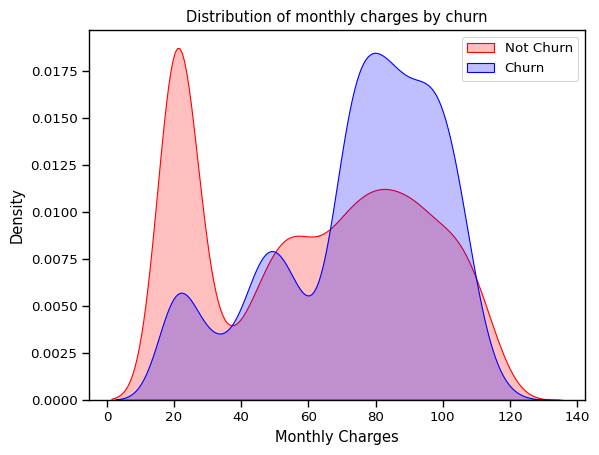

In [89]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(churn_df.MonthlyCharges[(churn_df["Churn"] == 'No') ],
                color="Red", fill = True);
ax = sns.kdeplot(churn_df.MonthlyCharges[(churn_df["Churn"] == 'Yes') ],
                ax =ax, color="Blue", fill= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Distribution of monthly charges by churn');


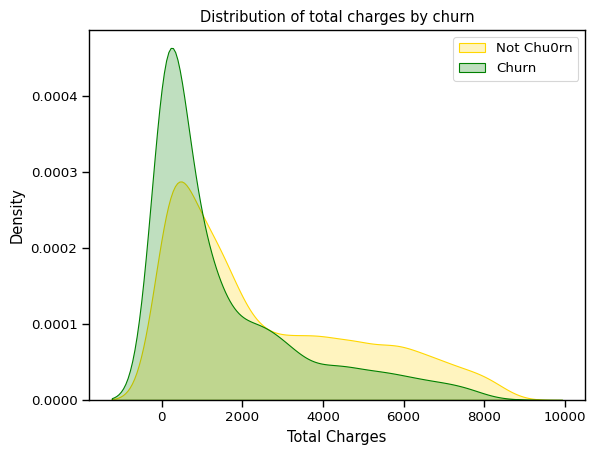

In [91]:
ax = sns.kdeplot(churn_df.TotalCharges[(churn_df["Churn"] == 'No') ],
                color="Gold", fill = True);
ax = sns.kdeplot(churn_df.TotalCharges[(churn_df["Churn"] == 'Yes') ],
                ax =ax, color="Green", fill= True);
ax.legend(["Not Chu0rn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Distribution of total charges by churn');

In [92]:
fig = px.box(churn_df, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()



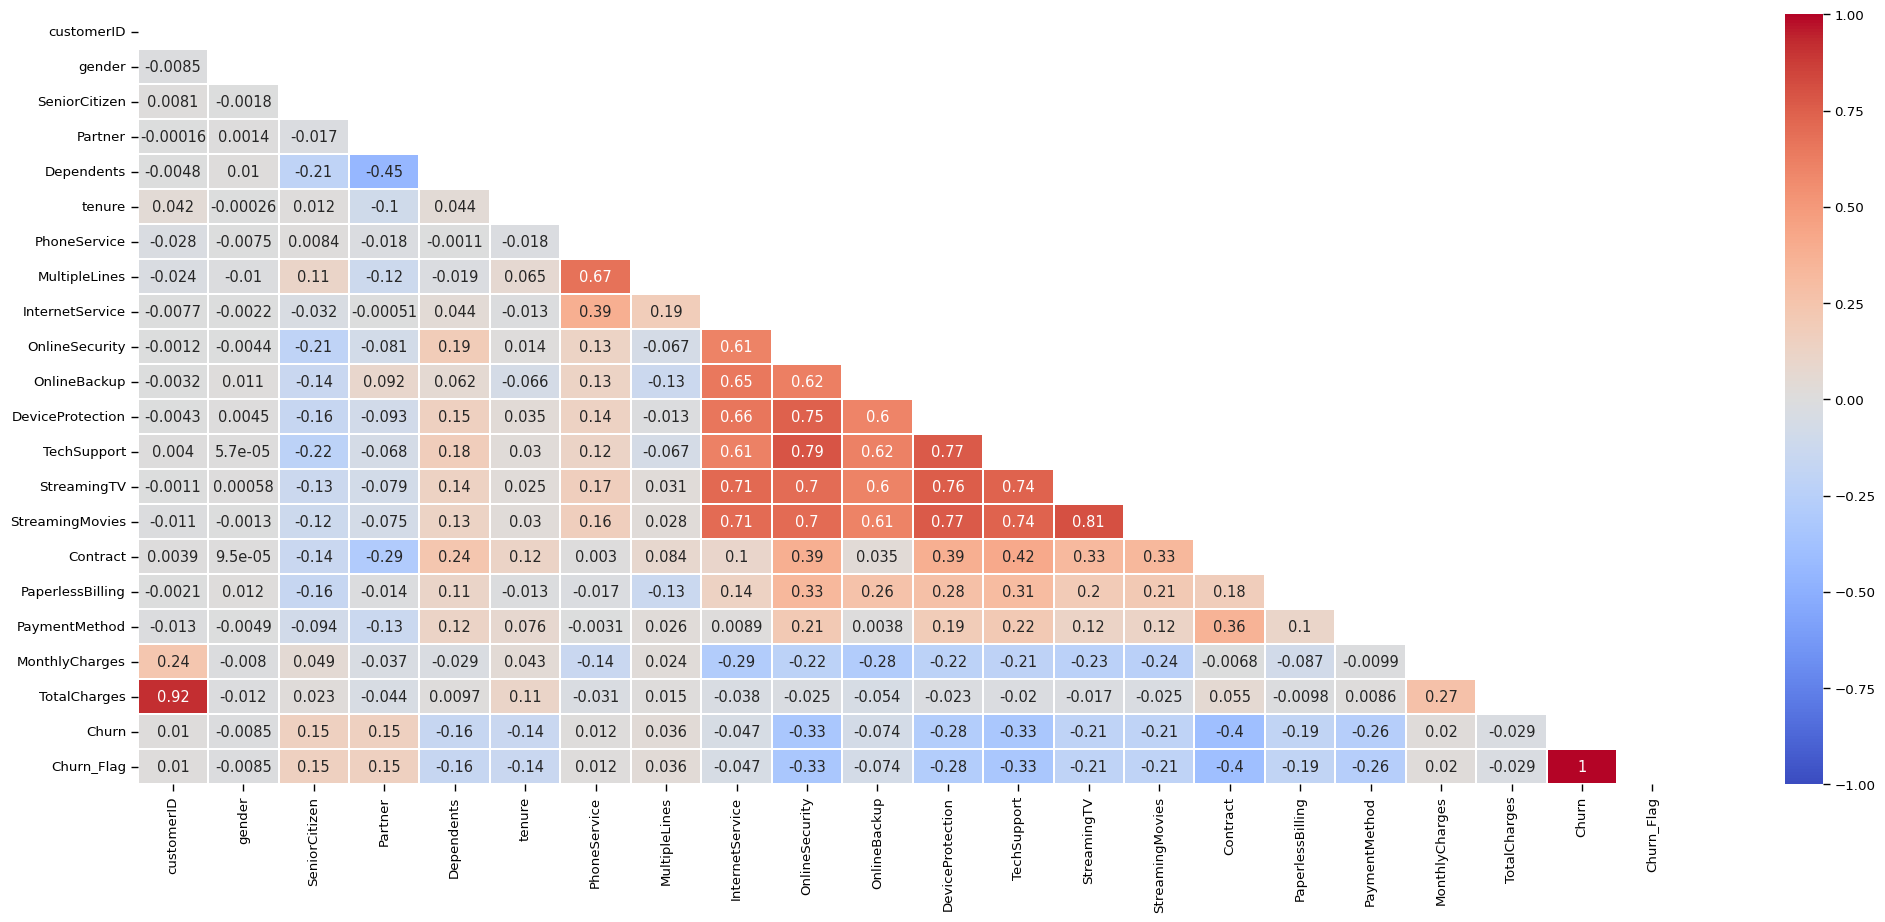

In [94]:
plt.figure(figsize=(25, 10))

corr = churn_df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

**Summary from EDA**

The dataset contains 7,043 customers with 21 features including demographic, service usage, and billing information. No major missing values were found, except in TotalCharges, which required cleaning.


Approximately 26.5% of customers have churned, indicating moderate class imbalance, which must be considered during model training.


* Customers on month-to-month contracts exhibit significantly higher churn compared to those on yearly plans.

* Short-tenure customers (less that 12 months) are more likely to churn.
* Customers using fiber optic internet show higher churn than DSL users.
* Higher monthly charges correlate positively with churn.
* Customers without technical support churn more frequently.


**The highest-risk segment consists of new customers on month-to-month contracts with high monthly charges and no additional services.**

These findings suggest that offering discounts to new customers, promoting long-term contracts, and bundling support services may help reduce churn.